In [1]:
%reload_ext autoreload
%autoreload 2
%cd ~/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory
%env PATH=$HOME/.local/bin:$PATH
    
import json
import os
import requests
import numpy as np
import cv2
from PIL import Image
from pymongo import MongoClient
# from mmdet.apis import init_detector, inference_detector
# from mmdet.utils import register_all_modules
from data_processing.divide_photos import divide_tablet_photo
from sign_alignment.detector import ModelConfig, TabletImageDetector
from sign_alignment.data_source import LocalDataSource, LocalTestDataSource, SubtabletEBLAPISource
from sign_alignment.visualizer import BboxVisualizer, ColorConfig

# import signs_alignment as sa
import os
import torch
from dotenv import load_dotenv

ANNOTATIONS_DIR = os.path.expanduser("~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations")
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser("~/erc-work-data/retrained_models/detr-173/epoch_1000.pth")
TEST_DATA_DIR = os.path.expanduser("~/erc-work-data/ready-for-training/coco-recognition-2025-09/data/coco")
# # temporal change
# CHECKPOINT_FILE = os.path.expanduser("~/epoch_1000.pth")
# ANNOTATIONS_DIR = os.path.expanduser("~/filtered_annotations")
# # ---
SCORE_THRESHOLD = 0.5
OUTPUT_DIR = "alignment_results"
SAMPLE_LIMIT = 5  # number of samples to process

load_dotenv()
MONGODB_URI = os.getenv('MONGODB_URI', 'YOUR_MONGODB_URI')


[Errno 2] No such file or directory: '/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree # Change to the project directory'
/home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree
env: PATH=$HOME/.local/bin:$PATH


/home/jebediahc/anaconda3/envs/cuneiform-ocr/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


classes setting in current coco.py: ['TU', '|U.GUD|', 'TUM', 'LA', 'TA', 'GAR', 'GAL', 'I', 'TI', 'LI', 'ZA', 'A', 'DI', 'MI', 'RI', 'IŠ', 'BA', 'LU', 'TE', 'DA', '|GUD×KUR|', 'MA', 'E₂', 'DIŠ', 'MU', 'DU', 'ŠU₂', 'EN', 'KUL', 'SI', '|I.A|', 'HI', 'MUŠ₃', 'AN', 'NA', 'BAD', 'AMAR', 'UD', 'UnclearSign', '|HI×BAD|', '|UD×(U.U.U)|', 'AB', 'AK', 'LUGAL', 'DIN', 'KI', 'DUN₃@g', 'KU₃', 'AŠ', 'IGI', 'U₂', 'ŠA₃', 'BI', 'GUR', 'ŠE', 'ZI', 'GA', 'SILA₃', 'ŠID', '|SAL.TUG₂|', 'SU', 'KAK', 'MAŠ', 'TUR', 'ŠEŠ', 'LU₂', 'IA₂', 'UR', 'KAL', '|ŠEŠ.KI|', 'ZU', 'ŠU', 'NE', 'IM', 'RA', '|U.U|', 'ZAG', '|DIŠ.DIŠ.DIŠ|', 'GA₂', 'IN', 'KIN', 'TAR', 'MAH', 'LAL', 'KID', 'GABA', 'KA', 'RU', 'ŠA', '|HI×NUN|', 'ME', 'BU', 'NI', 'IG', 'MES', 'PA', 'SAG', 'U', 'E', 'GUM', 'GIŠ', '|U.KA|', 'LUM', '|HI×AŠ₂|', 'HA', 'UŠ', '|U.U.U|', 'MIN', 'NAM', 'NU', 'AL', 'AB₂', 'IB', 'UM', 'KU', 'SUR', 'MEŠ', 'TUG₂', 'TAG', 'DIM', 'BAL', 'IR', 'ERIN₂', 'PAP', 'SA', '|PIRIG×ZA|', 'UB', 'URU', '|U.5(DIŠ)|', 'DAM', 'GAR₃', '|EN.ZU|',

In [2]:
from sign_alignment.pipeline import (
    CropContext, PipelineConfig, DEBUG_STEPS, DEBUG_STEPS_WITH_PROTOSNAP,
    Runner, VisOptions,
)
from sign_alignment.protosnap import ProtoSnapConfig

# Set repo_root to a local clone of TAU-VAILab/ProtoSnap to enable freeze.
# Leave it as None to keep the original behavior (everything still runs).
_PS_REPO = os.path.expanduser("~/erc-src/ProtoSnap")
ps_cfg = ProtoSnapConfig(
    repo_root=_PS_REPO if os.path.isdir(_PS_REPO) else None,
    snap_at_iter=10,      # mid-opt run-once iteration
)

model_config = ModelConfig(
    config_file=CONFIG_FILE,
    checkpoint_file=CHECKPOINT_FILE,
    device='auto'
)


if 'tablet_detector' not in globals() or getattr(tablet_detector, 'model', None) is None:
    tablet_detector = TabletImageDetector(
        model_config=model_config,
        score_threshold=SCORE_THRESHOLD,
        keep_crops=True,
        is_crop_itself=True,
    )
else:
    print("Reusing existing tablet_detector instance.")


crop_context = CropContext(
    config=PipelineConfig(
        model_config=model_config,
        tablet_detector=tablet_detector,
        local_source=LocalDataSource(ANNOTATIONS_DIR),
        color_config=ColorConfig,
        output_dir=OUTPUT_DIR,
        img_idx=1,
        protosnap=ps_cfg,
    )
)

crop_context_using_test_data = CropContext(
    config=PipelineConfig(
        model_config=model_config,
        tablet_detector=tablet_detector,
        local_source=LocalTestDataSource(TEST_DATA_DIR),
        api_source=SubtabletEBLAPISource(),
        color_config=ColorConfig,
        output_dir=OUTPUT_DIR,
        img_idx=1,
        protosnap=ps_cfg,
    )
)

# Control which visualization outputs are produced for all steps
vis = VisOptions(info=True, display=True, save=True)

runner = Runner(
    context=crop_context_using_test_data, # switch context here
    steps=DEBUG_STEPS_WITH_PROTOSNAP,
    vis=vis,
)

Initializing detector, loading model...
Using device: cuda:0
Loads checkpoint by local backend from path: /home/jebediahc/erc-work-data/retrained_models/detr-173/epoch_1000.pth
Found 100 fragments with both image and annotation


Processing sample: BM.34201-1
Step: Load Data (image, GT, sign text)
Ground truth boxes: 17
  Text lines: 33, total signs: 198
  Unfiltered: 313 signs, broken removed: 115
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_gt.jpg


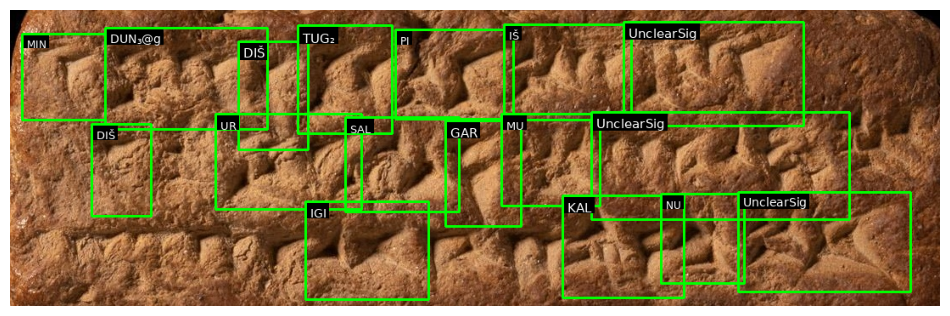

In [3]:
import sign_alignment.pipeline as pp

runner.choose_sample(9)  # index 0 = NBC.4020, index 9 = HS.2086
# Load image, ground truth, and sign text from API in one step
runner.run_single_step(pp.step_load_data)


Step: Detect Signs
Total detections (full image): 20
Sub-image detections: 20
Crop info (img_idx=1): x=0, y=0, w=1096, h=349
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_det.jpg
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_sub_image.jpg


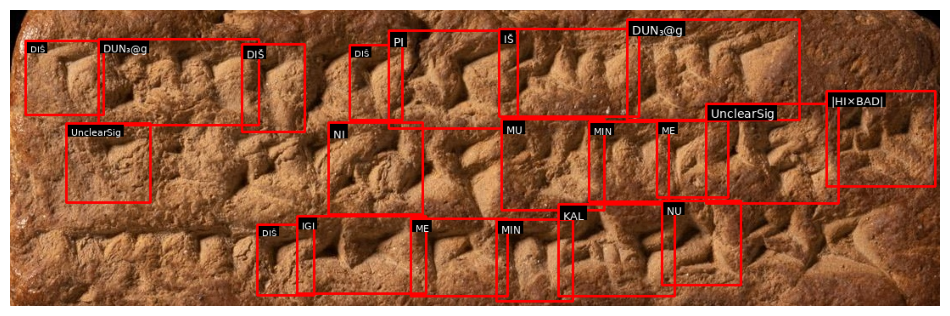

In [5]:
# detect signs (full image + chosen exp_image crop)
runner.run_single_step(pp.step_detect_signs)

Step: Transform GT to Sub-image Coords
GT boxes (full image): 17
GT boxes (sub-image):  17
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_sub_image_gt.jpg


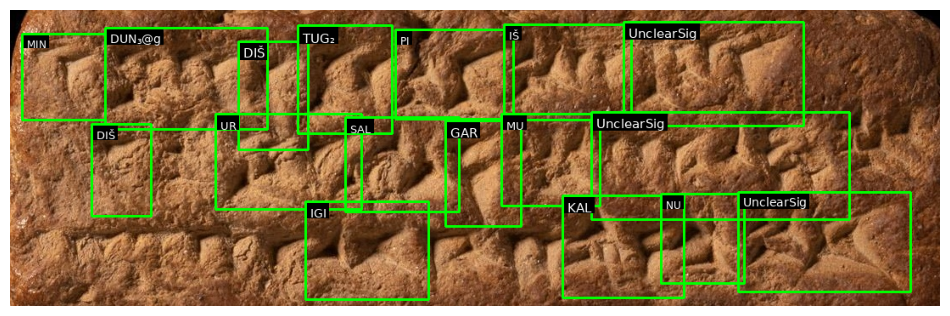

In [6]:
# transform GT boxes into sub-image coordinates and visualize
runner.run_single_step(pp.step_transform_gt_to_img)


In [7]:
# compute average detection box dimensions
runner.run_single_step(pp.step_compute_statistics)

Step: Compute Detection Statistics
Full image shape: (349, 1096, 3)
Sub-image shape:  (349, 1096, 3)
Average detected sign  width: 119.25
Average detected sign height: 100.20


In [8]:
# create detection and text sub-tablets
runner.run_single_step(pp.step_create_subtablets)

Step: Create Sub-tablets
SubTablet 'detection':
  20 signs, 1 rows, 
  image shape: (349, 1096, 3)
  avg_width: 119.25, avg_height: 100.20
SubTablet 'text':
  198 signs, 33 rows, 
  image shape: (349, 1096, 3)
  avg_width: 119.25, avg_height: 100.20


In [9]:
# DBSCAN row detection on detection sub-tablet (also reports text sub-tablet rows)
runner.run_single_step(pp.step_detect_rows)

Step: Detect Rows (DBSCAN)
=== Row Detection Results ===
Average sign size: 109.73 px, detected 3 rows, 20 signs
  Row 0: 7 boxes
  Row 1: 7 boxes
  Row 2: 6 boxes

=== Text SubTablet Row Info ===
Rows: 33, signs: 198
  Row 0: 5 signs
  Row 1: 5 signs
  Row 2: 7 signs
  Row 3: 6 signs
  Row 4: 2 signs
  Row 5: 10 signs
  Row 6: 8 signs
  Row 7: 2 signs
  Row 8: 13 signs
  Row 9: 9 signs
  Row 10: 8 signs
  Row 11: 10 signs
  Row 12: 6 signs
  Row 13: 7 signs
  Row 14: 8 signs
  Row 15: 9 signs
  Row 16: 9 signs
  Row 17: 10 signs
  Row 18: 12 signs
  Row 19: 4 signs
  Row 20: 8 signs
  Row 21: 8 signs
  Row 22: 3 signs
  Row 23: 6 signs
  Row 24: 4 signs
  Row 25: 4 signs
  Row 26: 3 signs
  Row 27: 3 signs
  Row 28: 3 signs
  Row 29: 1 signs
  Row 30: 2 signs
  Row 31: 1 signs
  Row 32: 2 signs


In [10]:
# DP row matching between detection and text sub-tablets
runner.run_single_step(pp.step_match_rows)

Step: Match Detection Rows to Text Rows
=== Row Matching ===
Detection rows: 3, Text rows: 33, Matched: 3
  Text row 13 (7 signs) → Det row 0 (7 signs)
    Text: MIN DUN₃@g DIŠ TUG₂ PI...
    Det:  DIŠ DUN₃@g DIŠ DIŠ PI...
  Text row 14 (8 signs) → Det row 1 (7 signs)
    Text: DIŠ LU₂ UR SAL GAR...
    Det:  UnclearSign NI MU MIN ME...
  Text row 15 (9 signs) → Det row 2 (6 signs)
    Text: MIN DUN₃@g DIŠ IGI ME...
    Det:  DIŠ IGI ME MIN KAL...
Text→Det: {13: 0, 14: 1, 15: 2}
Det→Text: {0: 13, 1: 14, 2: 15}


Step: Visualize Detection Rows
Detection rows: D# on left margin, matched rows show D#->R#


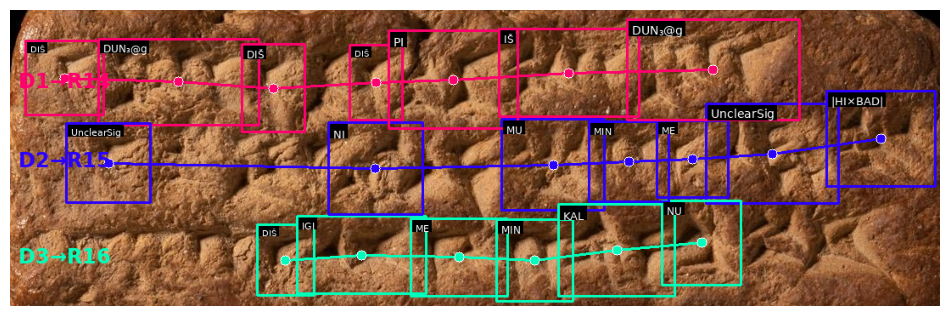

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_detection_rows.jpg


In [11]:
# visualize detection rows with D# / D#→R# labels
runner.run_single_step(pp.step_visualize_detection_rows)

In [12]:
# within-row sign matching for each matched row pair
runner.run_single_step(pp.step_match_signs_in_rows)

Step: Within-Row Sign Matching
=== Within-Row Sign Matching ===
Text row 13 -> Det row 0: 7 text, 7 det, 7 matched
  1. Text[0]=MIN <-> Det[0]=DIŠ
  2. Text[1]=DUN₃@g <-> Det[1]=DUN₃@g
  3. Text[2]=DIŠ <-> Det[2]=DIŠ
  4. Text[3]=TUG₂ <-> Det[3]=DIŠ
  5. Text[4]=PI <-> Det[4]=PI
  ... and 2 more
Text row 14 -> Det row 1: 8 text, 7 det, 7 matched
  1. Text[1]=LU₂ <-> Det[0]=UnclearSign
  2. Text[2]=UR <-> Det[1]=NI
  3. Text[3]=SAL <-> Det[2]=MU
  4. Text[4]=GAR <-> Det[3]=MIN
  5. Text[5]=MU <-> Det[4]=ME
  ... and 2 more
Text row 15 -> Det row 2: 9 text, 6 det, 6 matched
  1. Text[2]=DIŠ <-> Det[0]=DIŠ
  2. Text[3]=IGI <-> Det[1]=IGI
  3. Text[4]=ME <-> Det[2]=ME
  4. Text[5]=MIN <-> Det[3]=MIN
  5. Text[6]=KAL <-> Det[4]=KAL
  ... and 1 more
Total matched sign pairs: 20


In [13]:
# align text rows onto detection rows using regression baselines
# result stored in sub_tablet_aligned
runner.run_single_step(pp.step_align_text_rows)


Step: Align Text Rows to Detection Rows
=== Row Alignment Summary ===
Total aligned sign boxes: 24
Matched text rows aligned: 3
  Row 13: 7 signs
  Row 14: 8 signs
  Row 15: 9 signs


Step: Build Sign Match Info & Visualize Mapping
=== Sign Match Info ===
  Matched, same label:  11
  Matched, diff label:  9
  Unmatched text signs: 4
  Unmatched det signs:  0


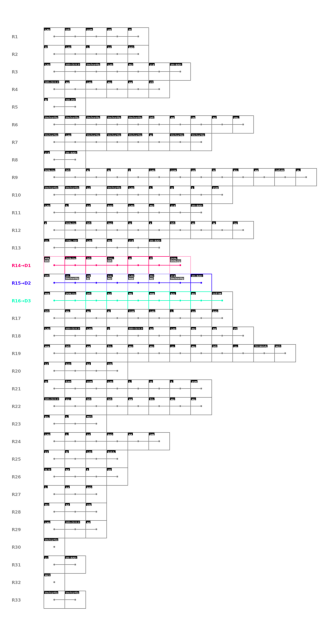

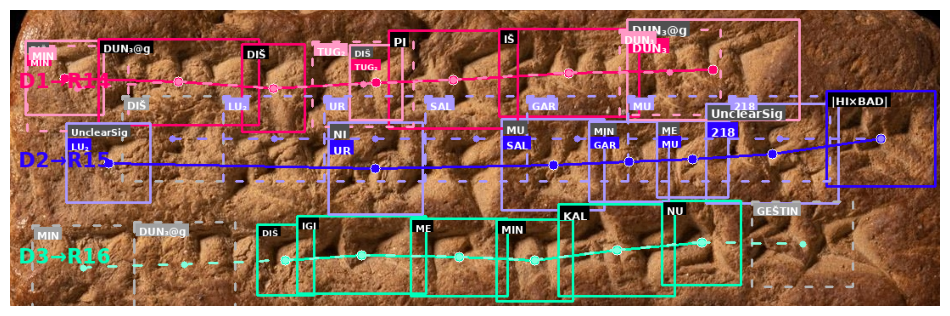

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_text_rows_mapped.jpg
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_rows_side_by_side.jpg
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_alignment_diagnostic.jpg


In [14]:
# build sign match info; draw text mapping, side-by-side composite, alignment diagnostic
runner.run_single_step(pp.step_build_sign_match_info)

In [15]:
# position offset analysis: coarse-aligned vs detection boxes
runner.run_single_step(pp.step_offset_analysis)


Step: Position Offset Analysis
=== Position Offset Analysis (coarse-aligned vs detection) ===
  Delta cx: mean=-0.77, std=51.65, |max|=195.09
  Delta cy: mean=-7.37, std=13.67, |max|=35.00
  Delta w : mean=2.51, std=27.03, |max|=83.76
  Delta h : mean=-0.01, std=7.73, |max|=17.40


In [16]:
# unload detector model from GPU to free VRAM before DIFT / PSR optimization
# runner.run_single_step(pp.step_unload_detector)

In [17]:
# ProtoSnap setup: resolve period/font, build CenterFreezeRefiner.
# Graceful no-op if repo_root or ABZ->Unicode map are missing.
# runner.run_single_step(pp.step_protosnap)


In [18]:
# create PSR optimizer and plot characteristic loss curves
runner.run_single_step(pp.step_create_psr_optimizer)

Step: Create PSR Optimizer
=== PSR Optimizer ===
  Device: cuda, Source (M): 24, Target (N): 20
  Sigma: 178.9, w_noise: 0.1
  Lambdas: data=2.0, anchor=0.01, seq=0.1, height=0.01, rows=5.0, boundary=0.0
  Contour mask: not set
Loss curve plots saved to alignment_loss_functions/:
  alignment_loss_functions/loss_rows.png
  alignment_loss_functions/loss_anchor.png
  alignment_loss_functions/loss_seq.png
  alignment_loss_functions/loss_height.png
  alignment_loss_functions/loss_data.png


In [19]:
# run PSR optimization (produces sub_tablet_final)
runner.run_single_step(pp.step_run_psr_optimization)

Step: Run PSR Optimization
Point Set Registration Optimizer
  Source (text):  24 signs, 3 rows
  Target (det):   20 signs
  Device:         cuda
  sigma:          178.9 → 44.7
  w_noise:        0.1
  Lambdas:  data=2.0, anchor=0.01, seq=0.1, height=0.01, rows=5.0, boundary=0.0
------------------------------------------------------------
Iter    0: total=41.3104  data=5.2983  anchor=8.8181  seq=281.1286  height=34.4325  rows=0.4337  boundary=0.0000  σ=178.9
Iter   20: total=12.5235  data=5.2983  anchor=2.1591  seq=6.4688  height=0.6489  rows=0.2504  boundary=0.0000  σ=144.9
Iter   40: total=10.7674  data=5.2982  anchor=4.7185  seq=0.5196  height=4.2490  rows=0.0059  boundary=0.0000  σ=110.9
Iter   60: total=10.6427  data=5.2982  anchor=1.1174  seq=0.1371  height=0.8737  rows=0.0025  boundary=0.0000  σ=77.0
Iter   79: total=10.6002  data=5.2980  anchor=0.0811  seq=0.0279  height=0.0410  rows=0.0000  boundary=0.0000  σ=44.7
=== Optimization Complete: 24 signs ===


In [20]:
# Blue = frozen centers, Orange = still being optimized.
# (Empty visualization if ProtoSnap was disabled or no signs were accepted.)
runner.run_single_step(pp.step_protosnap_freeze_vis)


Step: ProtoSnap Freeze Visualization (blue=frozen, orange=free)
ProtoSnap freeze visualization: nothing to show (refiner disabled or no signs accepted).


In [21]:
# Per-sign grid: prototype (left) | annotated crop (right)
# Cyan circle = original center, green/red cross = ProtoSnap center
runner.run_single_step(pp.step_protosnap_crop_vis)

Step: ProtoSnap Crop Grid (prototype | annotated crop per sign)
ProtoSnap crop grid: no refinements to show.


Step: Plot Loss History


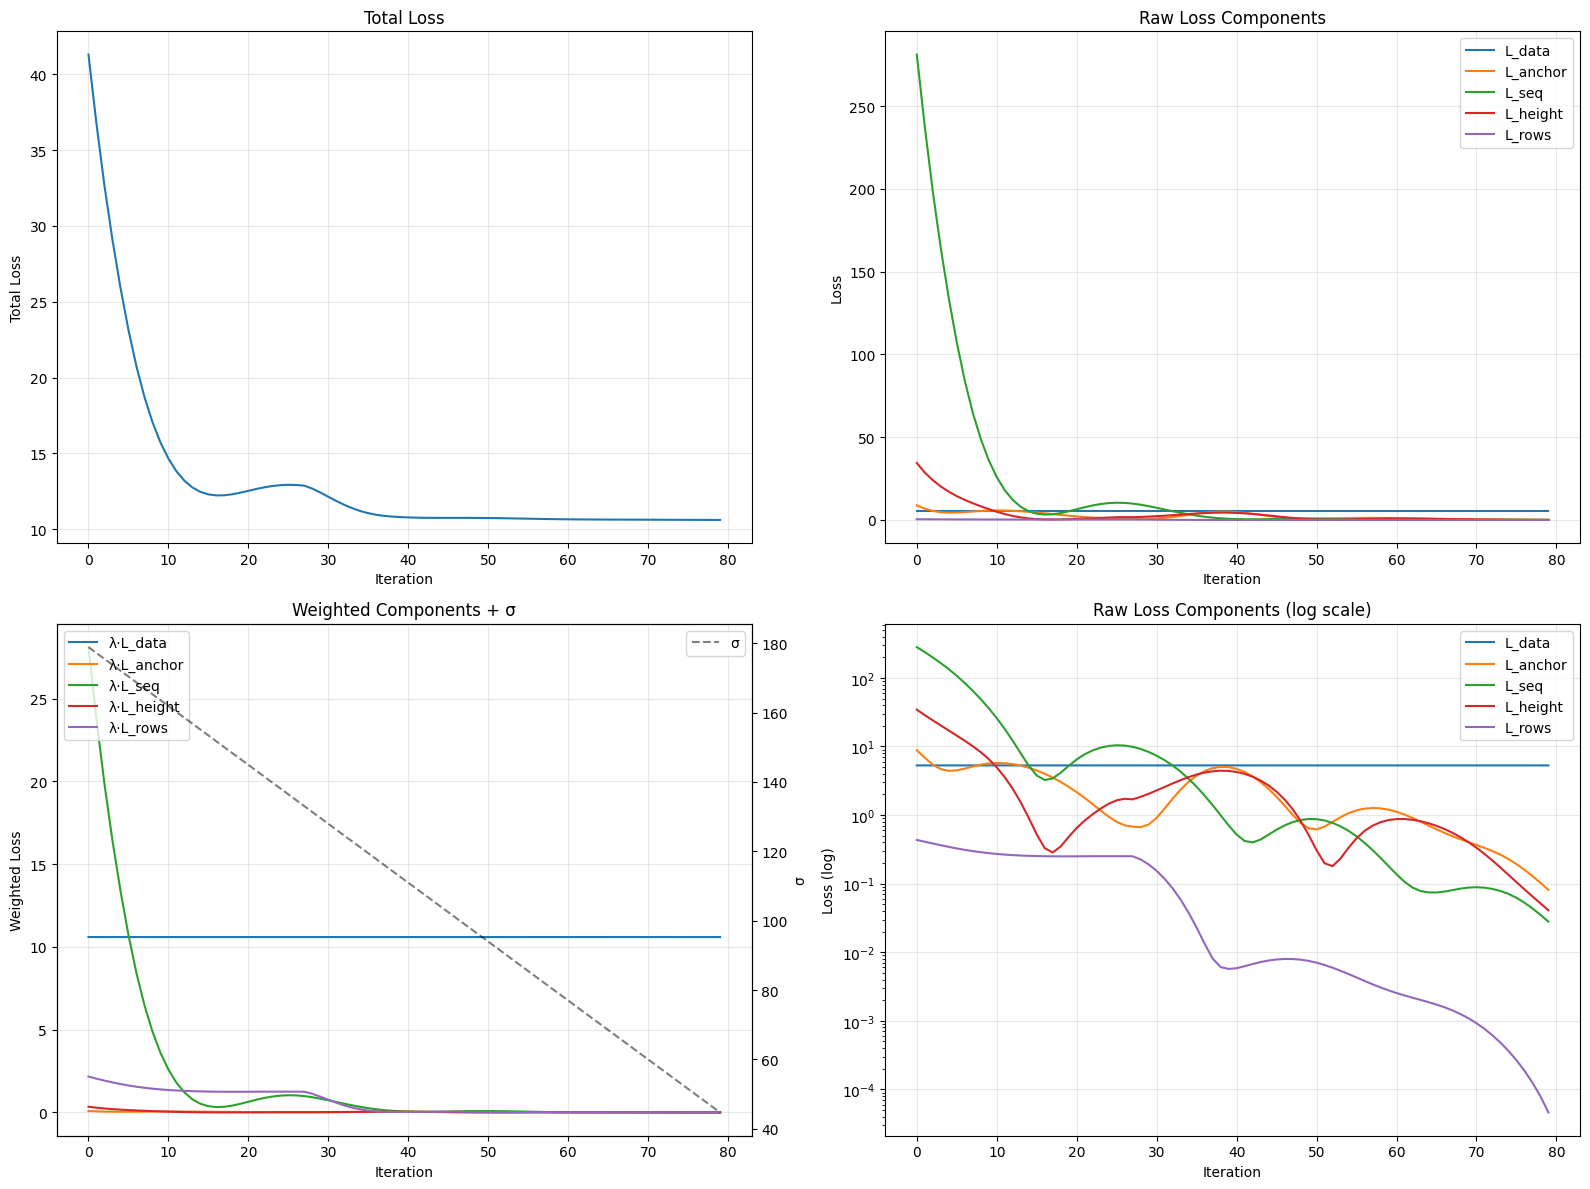

In [22]:
# optimization loss history
runner.run_single_step(pp.step_plot_loss_history)

Step: Results Comparison
Cyan=Coarse aligned  Yellow=Final optimized  Red=Detection  Green=GT


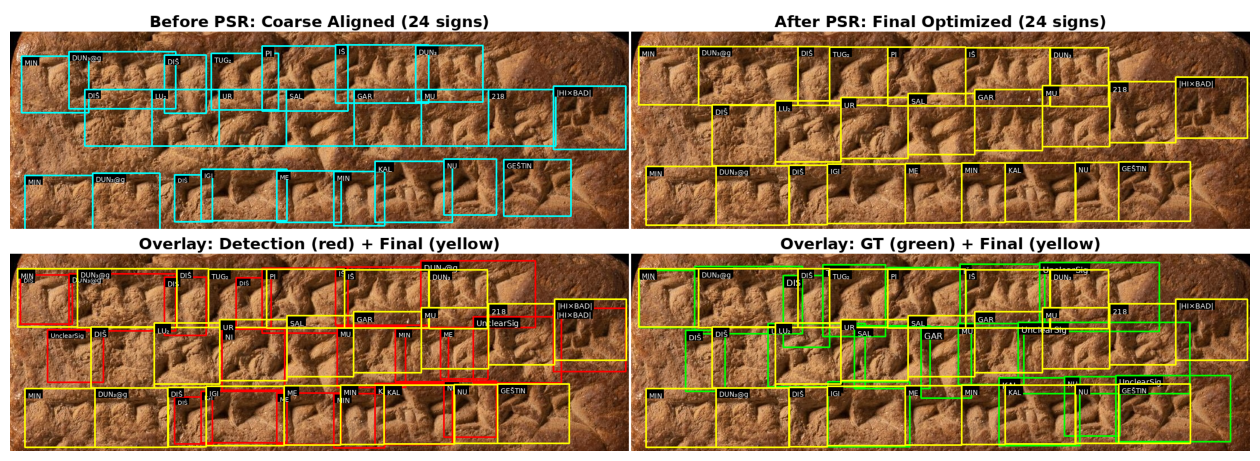

✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_coarse_aligned.jpg
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_final_optimized.jpg
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_overlay_det_final.jpg
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_overlay_gt_final.jpg
✓ Saved to: /home/jebediahc/erc-src/cuneiform-ocr-sign-alignment-worktree/alignment_results/debug_BM.34201-1_results_comparison.jpg


In [23]:
# 2x2 results comparison: coarse aligned, final optimized, det+final overlay, gt+final overlay
runner.run_single_step(pp.step_results_comparison)

In [24]:
# analyze parameter changes between coarse-aligned and final optimized
runner.run_single_step(pp.step_param_changes)

Step: Analyze Parameter Changes
=== Parameter Changes (Coarse -> Final) ===
  Delta cx: mean=2.37, std=7.68, |max|=15.84
  Delta cy: mean=-0.56, std=12.48, |max|=31.59
  Delta w : mean=-7.03, std=8.49, |max|=17.72
  Delta h : mean=5.22, std=6.44, |max|=21.55

=== First 5 Signs: Coarse -> Final ===
  1. MIN:
      Coarse: cx=79.7, cy=93.8, w=119.3, h=100.2
      Final:  cx=66.7,  cy=77.8, w=106.2,  h=103.3
      Delta:  cx=-13.1, cy=-16.0, w=-13.1, h=3.1
  2. DUN₃@g:
      Coarse: cx=199.0, cy=85.6, w=189.2, h=101.0
      Final:  cx=207.6,  cy=78.4, w=175.3,  h=103.3
      Delta:  cx=8.6, cy=-7.1, w=-13.9, h=2.3
  3. DIŠ:
      Coarse: cx=310.2, cy=93.2, w=74.1, h=102.6
      Final:  cx=323.6,  cy=78.6, w=56.3,  h=103.2
      Delta:  cx=13.4, cy=-14.6, w=-17.7, h=0.6
  4. TUG₂:
      Coarse: cx=416.3, cy=88.1, w=119.3, h=100.2
      Final:  cx=403.0,  cy=79.1, w=102.2,  h=103.3
      Delta:  cx=-13.3, cy=-9.1, w=-17.0, h=3.1
  5. PI:
      Coarse: cx=522.4, cy=83.1, w=152.8, h=115.3
   